# Continue Fine-tuning Qwen2.5 1.5B Instruct with QLoRA

This notebook is designed for repeated Kaggle runs:

1. Load the base Qwen model in 4-bit.
2. If `PREVIOUS_ADAPTER_PATH` is set, load that LoRA adapter as trainable.
3. Fine-tune on the configured parquet train data.
4. Save a new LoRA adapter to `OUTPUT_DIR/lora_adapter`.
5. For the next loop, publish that adapter as a Kaggle Dataset and set `PREVIOUS_ADAPTER_PATH` to it.

The base model is not merged. Only the LoRA adapter is saved.

In [1]:
!pip install -q -U transformers accelerate peft bitsandbytes datasets pandas pyarrow sentencepiece matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 99.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 109.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.4/684.4 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import json
import math
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import Dataset
from peft import LoraConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    DataCollatorForSeq2Seq,
    Trainer,
    TrainingArguments,
)

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 1. Run configuration

Fill these paths manually before running the notebook. The notebook will not auto-detect train/model/valid/adapter paths.

- `MODEL_PATH`: base Qwen model path.
- `TRAIN_PATH`: parquet used for this fine-tune loop.
- `VALID_PATH`: clean valid parquet.
- `PREVIOUS_ADAPTER_PATH`: old LoRA adapter folder, or empty string for a new adapter.
- `RESUME_FROM_CHECKPOINT`: Trainer checkpoint folder if you want to resume optimizer/scheduler state.


In [3]:
# Fill these paths manually.
MODEL_PATH = "/kaggle/input/models/qwen-lm/qwen2.5/transformers/1.5b-instruct/1"
TRAIN_PATH = "/kaggle/input/datasets/flowboat/nlp-augument/train_entity_substitution_deepseek_100pct_improved_alias_safe_aug_only.parquet"
VALID_PATH = "/kaggle/input/datasets/flowboat/nlp-code/valid-00000-of-00001.parquet"

# Empty string means: create a new LoRA adapter from the base model.
# Example: "/kaggle/input/previous-qwen-qlora/lora_adapter"
PREVIOUS_ADAPTER_PATH = "/kaggle/input/datasets/flowboat/qwen-after-train/qwen2_5_1_5b_qlora_summarization/lora_adapter"

# Optional Trainer checkpoint folder. This resumes optimizer/scheduler too.
# Example: "/kaggle/input/previous-qwen-qlora/checkpoint-1200"
RESUME_FROM_CHECKPOINT = ""

RUN_NAME = "qwen2_5_1_5b_continue_qlora"
OUTPUT_ROOT = Path("/kaggle/working" if Path("/kaggle/working").exists() else "artifacts")
OUTPUT_DIR = OUTPUT_ROOT / RUN_NAME
ADAPTER_DIR = OUTPUT_DIR / "lora_adapter"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ARTICLE_COL = "article"
SUMMARY_COL = "summary"

MAX_LENGTH = 3072
MAX_NEW_TOKENS = 220

NUM_EPOCHS = 1
MAX_STEPS = -1  # set > 0 to cap runtime on Kaggle
BATCH_SIZE = 1
GRAD_ACCUM = 8
LEARNING_RATE = 2e-4
WARMUP_STEPS = 50

EVAL_STEPS = 200
SAVE_STEPS = 200
LOGGING_STEPS = 20
SAVE_TOTAL_LIMIT = 2

LIMIT_TRAIN = None  # set to a small number like 64 for smoke test
LIMIT_VALID = None

for name, value in {
    "MODEL_PATH": MODEL_PATH,
    "TRAIN_PATH": TRAIN_PATH,
    "VALID_PATH": VALID_PATH,
}.items():
    if not value:
        raise ValueError(f"{name} must be filled before running this notebook.")

print("MODEL_PATH:", MODEL_PATH)
print("TRAIN_PATH:", TRAIN_PATH)
print("VALID_PATH:", VALID_PATH)
print("PREVIOUS_ADAPTER_PATH:", PREVIOUS_ADAPTER_PATH or "<new adapter>")
print("RESUME_FROM_CHECKPOINT:", RESUME_FROM_CHECKPOINT or "<none>")
print("OUTPUT_DIR:", OUTPUT_DIR)
print("ADAPTER_DIR:", ADAPTER_DIR)
print("LEARNING_RATE:", LEARNING_RATE)


MODEL_PATH: /kaggle/input/models/qwen-lm/qwen2.5/transformers/1.5b-instruct/1
TRAIN_PATH: /kaggle/input/datasets/flowboat/nlp-augument/train_entity_substitution_deepseek_100pct_improved_alias_safe_aug_only.parquet
VALID_PATH: /kaggle/input/datasets/flowboat/nlp-code/valid-00000-of-00001.parquet
PREVIOUS_ADAPTER_PATH: /kaggle/input/datasets/flowboat/qwen-after-train/qwen2_5_1_5b_qlora_summarization/lora_adapter
RESUME_FROM_CHECKPOINT: <none>
OUTPUT_DIR: /kaggle/working/qwen2_5_1_5b_continue_qlora
ADAPTER_DIR: /kaggle/working/qwen2_5_1_5b_continue_qlora/lora_adapter
LEARNING_RATE: 0.0002


## 2. Load train and valid data

Only `article` and `summary` are used for training. Extra augmentation audit columns are ignored.

In [4]:
def basic_clean_text(value):
    if pd.isna(value):
        return None
    return " ".join(str(value).split()).strip()


def load_split(path, split_name, limit=None):
    df = pd.read_parquet(path)
    missing = [col for col in [ARTICLE_COL, SUMMARY_COL] if col not in df.columns]
    if missing:
        raise ValueError(f"{split_name} missing columns: {missing}. Available columns: {df.columns.tolist()}")

    out = df[[ARTICLE_COL, SUMMARY_COL]].copy()
    out[ARTICLE_COL] = out[ARTICLE_COL].map(basic_clean_text)
    out[SUMMARY_COL] = out[SUMMARY_COL].map(basic_clean_text)
    rows_raw = len(out)
    out = out.dropna(subset=[ARTICLE_COL, SUMMARY_COL]).copy()
    out = out[(out[ARTICLE_COL].str.len() > 0) & (out[SUMMARY_COL].str.len() > 0)]
    out = out.drop_duplicates(subset=[ARTICLE_COL, SUMMARY_COL]).reset_index(drop=True)
    if limit is not None:
        out = out.head(limit).reset_index(drop=True)

    report = {
        "split": split_name,
        "path": str(path),
        "rows_raw": int(rows_raw),
        "rows_clean": int(len(out)),
        "article_word_mean": float(out[ARTICLE_COL].str.split().str.len().mean()),
        "summary_word_mean": float(out[SUMMARY_COL].str.split().str.len().mean()),
    }
    return out, report

train_df, train_report = load_split(TRAIN_PATH, "train", LIMIT_TRAIN)
valid_df, valid_report = load_split(VALID_PATH, "valid", LIMIT_VALID)

report_df = pd.DataFrame([train_report, valid_report])
report_df.to_csv(OUTPUT_DIR / "data_report.csv", index=False)
display(report_df)
print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)

,split,path,rows_raw,rows_clean,article_word_mean,summary_word_mean
0,train,/kaggle/input/datasets/flowboat/nlp-augument/t...,10775,10775,459.273225,104.711090
1,valid,/kaggle/input/datasets/flowboat/nlp-code/valid...,1349,1349,466.449963,102.068199


Train shape: (10775, 2)
Valid shape: (1349, 2)


## 3. Tokenizer and prompt

Use the pretrained Qwen tokenizer and the original chat template. The prompt is short to reduce token overhead.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    trust_remote_code=True,
    use_fast=True,
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

print("pad_token:", tokenizer.pad_token)
print("eos_token:", tokenizer.eos_token)
print("chat_template exists:", tokenizer.chat_template is not None)

pad_token: <|endoftext|>
eos_token: <|im_end|>
chat_template exists: True


In [6]:
def build_messages(article, summary=None):
    system_msg = "Bạn là trợ lý AI chuyên tóm tắt văn bản tiếng Việt chính xác, ngắn gọn và không thêm thông tin ngoài văn bản."
    user_msg = f"""Tóm tắt văn bản sau bằng tiếng Việt trong một đoạn văn.

Yêu cầu:
- Giữ các ý chính quan trọng.
- Giữ tên riêng, số liệu và ngày tháng quan trọng.
- Không bịa thêm thông tin ngoài văn bản.
- Không lặp ý.

Văn bản:
{article}

Tóm tắt:"""
    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg},
    ]
    if summary is not None:
        messages.append({"role": "assistant", "content": summary})
    return messages


def build_prompt(article):
    return tokenizer.apply_chat_template(
        build_messages(article, summary=None),
        tokenize=False,
        add_generation_prompt=True,
    )


def build_full_text(article, summary):
    text = tokenizer.apply_chat_template(
        build_messages(article, summary=summary),
        tokenize=False,
        add_generation_prompt=False,
    )
    if tokenizer.eos_token and not text.endswith(tokenizer.eos_token):
        text += tokenizer.eos_token
    return text

print(build_prompt(train_df.loc[0, ARTICLE_COL])[:1200])

<|im_start|>system
Bạn là trợ lý AI chuyên tóm tắt văn bản tiếng Việt chính xác, ngắn gọn và không thêm thông tin ngoài văn bản.<|im_end|>
<|im_start|>user
Tóm tắt văn bản sau bằng tiếng Việt trong một đoạn văn.

Yêu cầu:
- Giữ các ý chính quan trọng.
- Giữ tên riêng, số liệu và ngày tháng quan trọng.
- Không bịa thêm thông tin ngoài văn bản.
- Không lặp ý.

Văn bản:
Ngày 25/9, UBND TP Hà Nội cho phép Công ty cổ phần đầu tư xây dựng An Phú được chuyển nhượng một phần dự án Khu đô thị mới Tây Mỗ - Đại Mỗ - Vinhomes Park (tên thương mại Vinhomes Smart City) cho Công ty cổ phần HBC. Thái Sơn - công ty con của Vinhomes - có vai trò chủ đầu tư của đại đô thị Vinhomes Smart City. Trong khi, HBI là chủ đầu tư một số dự án căn hộ ở Hà Nội như Imperia Garden, Imperia Smart City. Năm 2019,HBI cũng từng nhận chuyển nhượng4 lô đất tại đại dự án này từ Thái Sơn với tổng diện tích hơn 33.400 m2. Phần dự án vừa được Hà Nội duyệt chuyển nhượng nằm tại các ô đất có ký hiệu F3-CH04-1, F3-CH04-2, F3-CH04

## 4. Token length report

This checks whether samples are truncated by `MAX_LENGTH`.

In [7]:
def token_len(text):
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])


def add_token_stats(df, split_name):
    rows = []
    for article, summary in tqdm(zip(df[ARTICLE_COL], df[SUMMARY_COL]), total=len(df), desc=f"Token stats {split_name}"):
        rows.append({
            "article_token_len": token_len(article),
            "summary_token_len": token_len(summary),
            "prompt_token_len": token_len(build_prompt(article)),
            "full_token_len": token_len(build_full_text(article, summary)),
        })
    stats = pd.DataFrame(rows)
    out = pd.concat([df.reset_index(drop=True), stats], axis=1)
    out["will_truncate_full"] = out["full_token_len"] > MAX_LENGTH
    return out

train_df = add_token_stats(train_df, "train")
valid_df = add_token_stats(valid_df, "valid")

print("Train samples > MAX_LENGTH:", int(train_df["will_truncate_full"].sum()), "/", len(train_df))
print("Valid samples > MAX_LENGTH:", int(valid_df["will_truncate_full"].sum()), "/", len(valid_df))

token_report = pd.concat([
    train_df[["article_token_len", "summary_token_len", "prompt_token_len", "full_token_len"]].describe().T.assign(split="train"),
    valid_df[["article_token_len", "summary_token_len", "prompt_token_len", "full_token_len"]].describe().T.assign(split="valid"),
]).reset_index().rename(columns={"index": "metric"})
token_report.to_csv(OUTPUT_DIR / "token_report.csv", index=False)
display(token_report)

Token stats train:   0%|          | 0/10775 [00:00<?, ?it/s]

Token stats valid:   0%|          | 0/1349 [00:00<?, ?it/s]

Train samples > MAX_LENGTH: 0 / 10775
Valid samples > MAX_LENGTH: 0 / 1349


,metric,count,mean,std,min,25%,50%,75%,max,split
0,article_token_len,10775.0,637.580418,142.669520,366.0,530.0,614.0,725.0,1133.0,train
1,summary_token_len,10775.0,141.304687,30.634008,59.0,118.0,138.0,163.0,248.0,train
2,prompt_token_len,10775.0,745.947935,142.618948,475.0,639.0,723.0,833.0,1241.0,train
3,full_token_len,10775.0,890.252622,152.598304,549.0,778.0,868.0,981.0,1443.0,train
4,article_token_len,1349.0,645.593032,141.696220,369.0,540.0,625.0,735.0,1090.0,valid
5,summary_token_len,1349.0,137.487027,29.542971,60.0,115.0,134.0,157.0,265.0,valid
6,prompt_token_len,1349.0,753.963677,141.642409,477.0,649.0,733.0,843.0,1199.0,valid
7,full_token_len,1349.0,894.450704,150.082801,587.0,784.0,876.0,991.0,1373.0,valid


## 5. Load base model and adapter

If `PREVIOUS_ADAPTER_PATH` is non-empty, load it with `is_trainable=True`. Otherwise, create a new LoRA adapter.


In [8]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
base_model.config.use_cache = False
base_model = prepare_model_for_kbit_training(base_model)

if PREVIOUS_ADAPTER_PATH:
    print("Loading previous LoRA adapter:", PREVIOUS_ADAPTER_PATH)
    model = PeftModel.from_pretrained(
        base_model,
        PREVIOUS_ADAPTER_PATH,
        is_trainable=True,
    )
else:
    print("No previous adapter. Creating a new LoRA adapter.")
    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=[
            "q_proj", "k_proj", "v_proj", "o_proj",
            "gate_proj", "up_proj", "down_proj",
        ],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
    )
    model = get_peft_model(base_model, lora_config)

model.print_trainable_parameters()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading previous LoRA adapter: /kaggle/input/datasets/flowboat/qwen-after-train/qwen2_5_1_5b_qlora_summarization/lora_adapter
trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


## 6. Tokenize for supervised fine-tuning

The prompt is masked with `-100`; loss is computed only on the assistant summary.

In [9]:
def tokenize_example(example):
    article = example[ARTICLE_COL]
    summary = example[SUMMARY_COL]

    prompt_text = build_prompt(article)
    full_text = build_full_text(article, summary)

    prompt_ids = tokenizer(
        prompt_text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )["input_ids"]

    full = tokenizer(
        full_text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )

    input_ids = full["input_ids"]
    attention_mask = full["attention_mask"]
    labels = input_ids.copy()
    prompt_len = min(len(prompt_ids), len(labels))
    labels[:prompt_len] = [-100] * prompt_len

    if all(x == -100 for x in labels):
        labels[-1] = input_ids[-1]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "length": len(input_ids),
    }

train_dataset = Dataset.from_pandas(train_df[[ARTICLE_COL, SUMMARY_COL]], preserve_index=False)
valid_dataset = Dataset.from_pandas(valid_df[[ARTICLE_COL, SUMMARY_COL]], preserve_index=False)

tokenized_train = train_dataset.map(tokenize_example, remove_columns=train_dataset.column_names, desc="Tokenizing train")
tokenized_valid = valid_dataset.map(tokenize_example, remove_columns=valid_dataset.column_names, desc="Tokenizing valid")

print(tokenized_train)
print(tokenized_valid)

Tokenizing train:   0%|          | 0/10775 [00:00<?, ? examples/s]

Tokenizing valid:   0%|          | 0/1349 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels', 'length'],
    num_rows: 10775
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels', 'length'],
    num_rows: 1349
})


## 7. Continue QLoRA training

`RESUME_FROM_CHECKPOINT` resumes Trainer optimizer and scheduler state. `PREVIOUS_ADAPTER_PATH` only continues from old adapter weights and creates a fresh optimizer.

In [10]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt",
)

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    max_steps=MAX_STEPS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    lr_scheduler_type="cosine",
    logging_steps=LOGGING_STEPS,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=SAVE_TOTAL_LIMIT,
    fp16=True,
    bf16=False,
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,
    max_grad_norm=0.3,
    report_to="none",
    remove_unused_columns=False,
    load_best_model_at_end=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_valid,
    data_collator=data_collator,
    processing_class=tokenizer,
)

run_config = {
    "model_path": MODEL_PATH,
    "train_path": TRAIN_PATH,
    "valid_path": VALID_PATH,
    "previous_adapter_path": PREVIOUS_ADAPTER_PATH,
    "resume_from_checkpoint": RESUME_FROM_CHECKPOINT,
    "output_dir": str(OUTPUT_DIR),
    "adapter_dir": str(ADAPTER_DIR),
    "max_length": MAX_LENGTH,
    "num_epochs": NUM_EPOCHS,
    "max_steps": MAX_STEPS,
    "batch_size": BATCH_SIZE,
    "grad_accum": GRAD_ACCUM,
    "learning_rate": LEARNING_RATE,
    "warmup_steps": WARMUP_STEPS,
}
(OUTPUT_DIR / "run_config.json").write_text(json.dumps(run_config, ensure_ascii=False, indent=2), encoding="utf-8")

trainer.train(resume_from_checkpoint=RESUME_FROM_CHECKPOINT or None)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
200,0.330519,0.549238
400,0.339046,0.553721
600,0.318335,0.544587
800,0.315884,0.543125
1000,0.324777,0.539433
1200,0.320202,0.536670
1347,0.324275,0.536597


TrainOutput(global_step=1347, training_loss=0.33454924702378847, metrics={'train_runtime': 20648.3211, 'train_samples_per_second': 0.522, 'train_steps_per_second': 0.065, 'total_flos': 7.647917017637683e+16, 'train_loss': 0.33454924702378847, 'epoch': 1.0})

## 8. Training loss chart

This cell extracts train loss and validation loss from `trainer.state.log_history`, saves them to CSV, and plots both curves on the notebook.


Saved trainer log history to: /kaggle/working/qwen2_5_1_5b_continue_qlora/trainer_log_history.csv
Saved train loss to: /kaggle/working/qwen2_5_1_5b_continue_qlora/train_loss_history.csv
Saved eval loss to: /kaggle/working/qwen2_5_1_5b_continue_qlora/eval_loss_history.csv
Saved loss plot to: /kaggle/working/qwen2_5_1_5b_continue_qlora/loss_curve.png


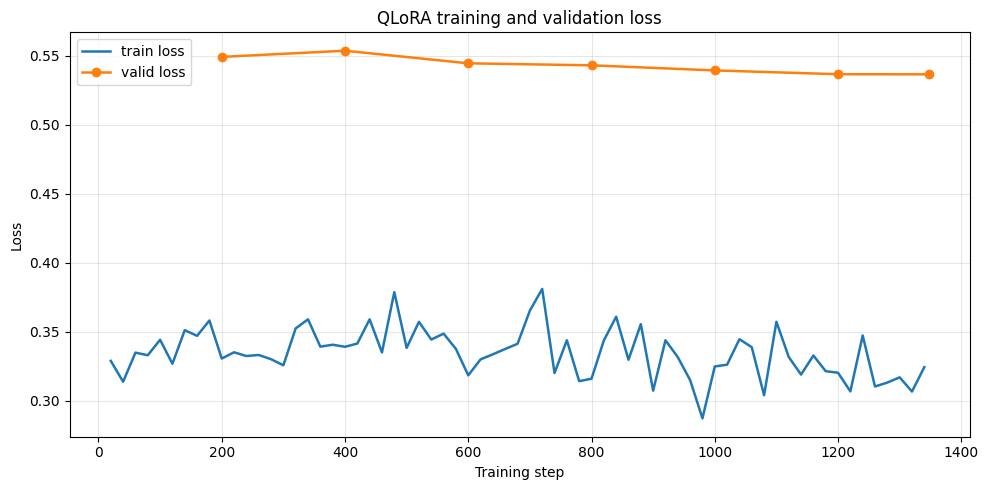

,metric,count
0,train_loss_points,67
1,eval_loss_points,7


In [11]:
log_history = trainer.state.log_history
log_df = pd.DataFrame(log_history)
LOG_HISTORY_PATH = OUTPUT_DIR / "trainer_log_history.csv"
log_df.to_csv(LOG_HISTORY_PATH, index=False)
print("Saved trainer log history to:", LOG_HISTORY_PATH)

train_loss_df = log_df.loc[log_df["loss"].notna(), ["step", "epoch", "loss"]].copy() if "loss" in log_df.columns else pd.DataFrame(columns=["step", "epoch", "loss"])
eval_loss_df = log_df.loc[log_df["eval_loss"].notna(), ["step", "epoch", "eval_loss"]].copy() if "eval_loss" in log_df.columns else pd.DataFrame(columns=["step", "epoch", "eval_loss"])

TRAIN_LOSS_PATH = OUTPUT_DIR / "train_loss_history.csv"
EVAL_LOSS_PATH = OUTPUT_DIR / "eval_loss_history.csv"
train_loss_df.to_csv(TRAIN_LOSS_PATH, index=False)
eval_loss_df.to_csv(EVAL_LOSS_PATH, index=False)
print("Saved train loss to:", TRAIN_LOSS_PATH)
print("Saved eval loss to:", EVAL_LOSS_PATH)

plt.figure(figsize=(10, 5))
if not train_loss_df.empty:
    plt.plot(train_loss_df["step"], train_loss_df["loss"], label="train loss", linewidth=1.8)
if not eval_loss_df.empty:
    plt.plot(eval_loss_df["step"], eval_loss_df["eval_loss"], label="valid loss", marker="o", linewidth=1.8)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("QLoRA training and validation loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
LOSS_PLOT_PATH = OUTPUT_DIR / "loss_curve.png"
plt.savefig(LOSS_PLOT_PATH, dpi=160)
print("Saved loss plot to:", LOSS_PLOT_PATH)
plt.show()

display(pd.DataFrame({
    "metric": ["train_loss_points", "eval_loss_points"],
    "count": [len(train_loss_df), len(eval_loss_df)],
}))


## 9. Save the new adapter

The `lora_adapter` folder is the artifact for the next loop.

In [12]:
trainer.save_model(str(ADAPTER_DIR))
tokenizer.save_pretrained(str(ADAPTER_DIR))
print("Saved LoRA adapter to:", ADAPTER_DIR)
print("Files:", sorted(p.name for p in ADAPTER_DIR.iterdir()))

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Saved LoRA adapter to: /kaggle/working/qwen2_5_1_5b_continue_qlora/lora_adapter
Files: ['README.md', 'adapter_config.json', 'adapter_model.safetensors', 'chat_template.jinja', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']


## 10. Evaluate validation loss

Use the separate benchmark notebook for ROUGE/BLEU/BERTScore generation metrics.

In [13]:
eval_metrics = trainer.evaluate(eval_dataset=tokenized_valid)
print(eval_metrics)

if "eval_loss" in eval_metrics:
    ppl = math.exp(eval_metrics["eval_loss"]) if eval_metrics["eval_loss"] < 20 else float("inf")
    print("Validation perplexity:", ppl)

pd.DataFrame([eval_metrics]).to_csv(OUTPUT_DIR / "eval_loss_metrics.csv", index=False)

Training Loss,Validation Loss,Step
0.324275,0.536597,1347


{'eval_loss': 0.5365968942642212}
Validation perplexity: 1.7101770347754


## 11. Smoke inference

This is only a quick check that the newly saved adapter can generate text.

In [14]:
@torch.inference_mode()
def summarize_after_finetune(article, max_new_tokens=MAX_NEW_TOKENS):
    prompt = build_prompt(article)
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )
    inputs = {key: value.to(model.device) for key, value in inputs.items()}
    output_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        repetition_penalty=1.05,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

idx = 0
print("REFERENCE:")
print(valid_df.loc[idx, SUMMARY_COL])
print("PREDICTION:")
print(summarize_after_finetune(valid_df.loc[idx, ARTICLE_COL]))

REFERENCE:
InterContinental Phu Quoc Long Beach Resort đã được vinh danh là khu nghỉ dưỡng gia đình tốt nhất châu Á lần thứ 2 liên tiếp. Khu nghỉ dưỡng này tọa lạc bên biển Phú Quốc, nổi bật với thiết kế lấy cảm hứng từ đại dương. Khu nghỉ dưỡng cung cấp nhiều trải nghiệm giải trí, thư giãn đa dạng, phù hợp với mọi độ tuổi. Du khách có thể chọn nghỉ ngơi tại khu phòng khách sạn rộng rãi, tiện nghi, hoặc những căn hộ, phòng suite, biệt thự cao cấp hướng biển. Ngoài ra, khu nghỉ dưỡng cũng cung cấp nhiều dịch vụ cao cấp như Club InterContinental Lounge, HARNN Heritage Spa, và các nhà hàng, quán bar sang trọng.
PREDICTION:
InterContinental Phu Quoc Long Beach Resort đã được vinh danh ở hạng mục gia đình trên toàn châu Á bởi World Travel Awards. Khu nghỉ dưỡng này nổi bật với thiết kế lấy cảm hứng từ đại dương, khuôn viên rộng rãi với nhiều mảng xanh thiên nhiên đậm chất nhiệt đới. Du khách có thể chọn nghỉ ngơi tại khu phòng khách sạn rộng rãi, tiện nghi, hoặc những căn hộ, phòng suite, b